Univariate LSTM forecasting per bridge

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os

In [2]:
DATA_PATH = "2017 Monthly Bike Count Totals for East River Bridges"

In [3]:
def load_data():
    dfs = []

    for f in os.listdir(DATA_PATH):
        if f.endswith(".xlsx"):

            df = pd.read_excel(
                os.path.join(DATA_PATH, f),
                header=5,
                usecols="B:K"
            )

            df.columns = df.columns.str.lower()
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df = df[df["date"].notna()]

            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df = df.sort_values("date")
    df = df.reset_index(drop=True)

    return df

In [4]:
df = load_data()

In [5]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [8]:
def train_model(model, loader, criterion, optimizer):
    model.train()
    for X, y in loader:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output.squeeze(), y)
        loss.backward()
        optimizer.step()

In [9]:
def evaluate(preds, y_test):
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return preds, mae, rmse

In [10]:
LOOKBACK = 14
EPOCHS = 100
BATCH_SIZE = 8
LR = 0.001

In [11]:
def run_lstm(series, bridge_name):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.values.reshape(-1, 1)).flatten()

    X, y = create_sequences(scaled, LOOKBACK)

    split = int(len(X) * 0.7)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    train_ds = TimeSeriesDataset(X_train.reshape(-1, LOOKBACK, 1), y_train)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    model = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        train_model(model, train_loader, criterion, optimizer)

    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_test.reshape(-1, LOOKBACK, 1), dtype=torch.float32)).numpy().squeeze()

    # inverse scale
    preds = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    preds, mae, rmse = evaluate(preds, y_test)

    print(f"\n=== LSTM - {bridge_name} ===")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

    plt.figure()
    plt.plot(y_test, label="Actual")
    plt.plot(preds, label="Predicted")
    plt.title(f"LSTM Forecast - {bridge_name}")
    plt.legend()
    plt.show()


=== LSTM - brooklyn bridge ===
MAE: 602.09, RMSE: 793.17


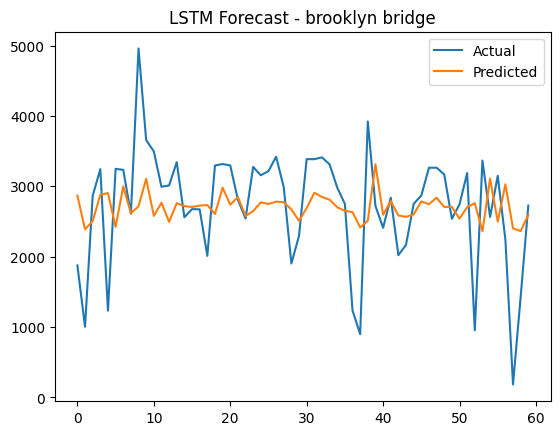


=== LSTM - manhattan bridge ===
MAE: 1181.89, RMSE: 1506.67


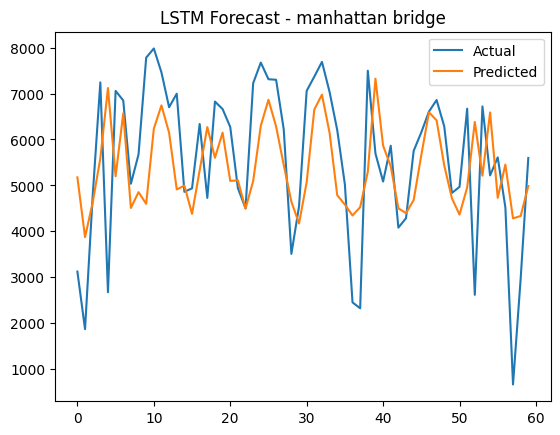


=== LSTM - williamsburg bridge ===
MAE: 1114.51, RMSE: 1525.79


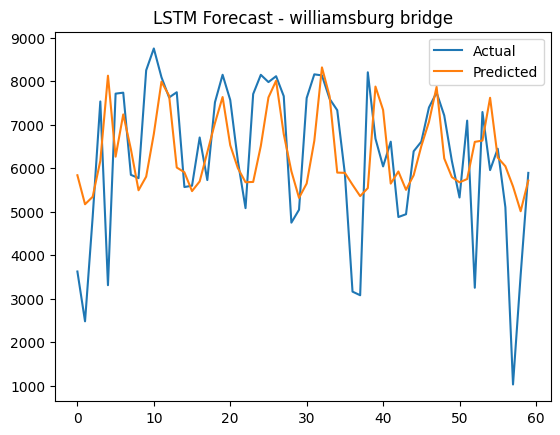


=== LSTM - queensboro bridge ===
MAE: 981.32, RMSE: 1324.73


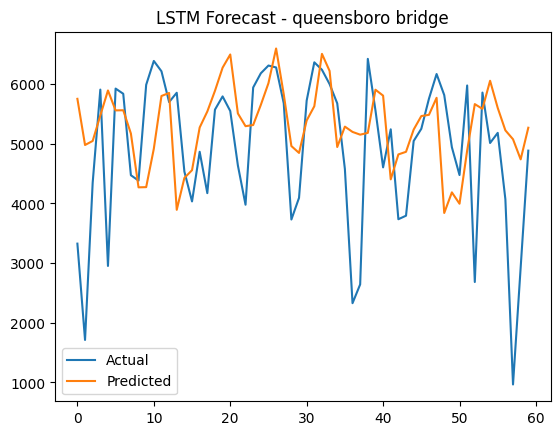

In [12]:
bridges = [
    "brooklyn bridge",
    "manhattan bridge",
    "williamsburg bridge",
    "queensboro bridge"
]

for b in bridges:
    series = df[b].dropna()
    run_lstm(series, b)